Loading and processing data from ECGIDld2_db/ ...
Successfully loaded 450 resting heartbeats and 450 exercise heartbeats.


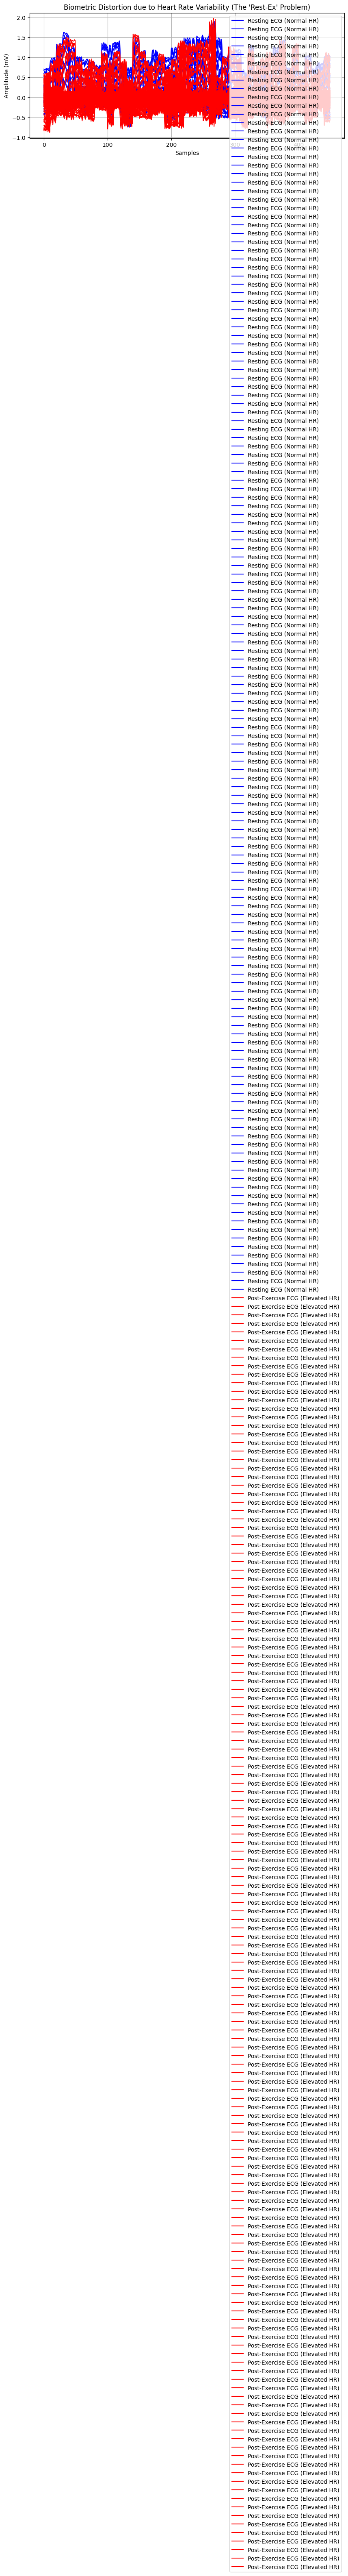

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================================================================
# CONFIGURATION & FUNCTIONS
# ==============================================================================
DB_PATH = "ECGIDld2_db"
FS = 300 # Sampling frequency
NUM_SUBJECTS = 45

def preprocess_signal(raw_ecg, fs=300):
    """4th-order Butterworth Bandpass Filter (0.5 Hz - 40 Hz)"""
    nyquist = 0.5 * fs
    b, a = butter(4, [0.5 / nyquist, 40.0 / nyquist], btype='bandpass')
    return filtfilt(b, a, raw_ecg)

def extract_pqrst(clean_ecg, fs=300):
    """Detects R-peaks and extracts a 150-sample (0.5s) window"""
    peaks, _ = find_peaks(clean_ecg, distance=int(fs*0.5), height=0.2)
    left_win = 48  # 0.16s before R-peak
    right_win = 102 # 0.34s after R-peak
    
    fragments = []
    for peak in peaks:
        if peak - left_win >= 0 and peak + right_win < len(clean_ecg):
            fragment = clean_ecg[peak - left_win : peak + right_win]
            fragment = fragment - np.mean(fragment) # Baseline zeroing
            fragments.append(fragment)
    return peaks, np.array(fragments)

# ==============================================================================
# DATA LOADING: PROCESSING ALL 90 FILES
# ==============================================================================
print(f"Loading and processing data from {DB_PATH}/ ...")

X_rest, y_rest = [], []
X_exercise, y_exercise = [], []

for subject_id in range(1, NUM_SUBJECTS + 1):
    rest_file = f"{DB_PATH}/{2 * subject_id - 1}.txt" # Odd files: 1, 3, 5...
    ex_file = f"{DB_PATH}/{2 * subject_id}.txt"       # Even files: 2, 4, 6...
    
    # 1. Process Resting Data (Pre-Exercise)
    if os.path.exists(rest_file):
        clean_rest = preprocess_signal(np.loadtxt(rest_file))
        _, frags_rest = extract_pqrst(clean_rest)
        for frag in frags_rest[:10]: # Extract 10 beats per subject
            X_rest.append(frag)
            y_rest.append(subject_id)
            
    # 2. Process Exercise Data (Post-Exercise)
    if os.path.exists(ex_file):
        clean_ex = preprocess_signal(np.loadtxt(ex_file))
        _, frags_ex = extract_pqrst(clean_ex)
        for frag in frags_ex[:10]: # Extract 10 beats per subject
            X_exercise.append(frag)
            y_exercise.append(subject_id)

X_rest, y_rest = np.array(X_rest), np.array(y_rest)
X_exercise, y_exercise = np.array(X_exercise), np.array(y_exercise)

print(f"Successfully loaded {len(X_rest)} resting heartbeats and {len(X_exercise)} exercise heartbeats.")

# ==============================================================================
# VISUALIZATION 1: The "Rest-Ex" Morphological Change
# ==============================================================================
# Let's plot Subject 1's resting beat vs exercise beat to show the distortion
plt.figure(figsize=(10, 4))
plt.plot(X_rest, label="Resting ECG (Normal HR)", color='blue')
plt.plot(X_exercise, label="Post-Exercise ECG (Elevated HR)", color='red')
plt.title("Biometric Distortion due to Heart Rate Variability (The 'Rest-Ex' Problem)")
plt.xlabel("Samples"); plt.ylabel("Amplitude (mV)")
plt.legend(); plt.grid(True); plt.show()

In [4]:
# ==============================================================================
# FEATURE SPACE REDUCTION (PCA)
# ==============================================================================
print("\nCompressing 150-sample arrays into 30 Principal Components...")

# We fit the PCA ONLY on the resting data (how a biometric lock is normally registered)
pca = PCA(n_components=30)
X_rest_pca = pca.fit_transform(X_rest)
X_exercise_pca = pca.transform(X_exercise)


Compressing 150-sample arrays into 30 Principal Components...


In [5]:
# ==============================================================================
# CLASSIFICATION & IDENTIFICATION (THE GRAND DEMONSTRATION)
# ==============================================================================
# Split the RESTING data into 70% Training (Database) and 30% Testing (Live Scans)
X_train, X_test, y_train, y_test = train_test_split(X_rest_pca, y_rest, test_size=0.3, random_state=42)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# --- TEST 1: NORMAL CONDITIONS (Rest-Rest) ---
y_pred_rest = lda.predict(X_test)
acc_rest = accuracy_score(y_test, y_pred_rest)

# --- TEST 2: EXERCISE CONDITIONS (Rest-Ex) ---
# Testing the system when users have an elevated heart rate
y_pred_ex = lda.predict(X_exercise_pca)
acc_ex = accuracy_score(y_exercise, y_pred_ex)

print("\n" + "="*50)
print("     CARDIOKEY BIOMETRIC AUTHENTICATION RESULTS")
print("="*50)
print(f"1. Baseline Accuracy (Normal Resting State): {acc_rest * 100:.2f}%")
print(f"   (Demonstrates the lock works across all {NUM_SUBJECTS} subjects)")
print("-" * 50)
print(f"2. Post-Exercise Accuracy (Elevated HR)    : {acc_ex * 100:.2f}%")
print("   (Demonstrates the known 'Rest-Ex' vulnerability where")
print("    shortened QT intervals cause identification failure)")
print("="*50)


     CARDIOKEY BIOMETRIC AUTHENTICATION RESULTS
1. Baseline Accuracy (Normal Resting State): 99.26%
   (Demonstrates the lock works across all 45 subjects)
--------------------------------------------------
2. Post-Exercise Accuracy (Elevated HR)    : 14.67%
   (Demonstrates the known 'Rest-Ex' vulnerability where
    shortened QT intervals cause identification failure)
